In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('ggplot')

print("✅ Imports done")

✅ Imports done


In [2]:
# Point this to wherever your CSVs are
DATA_DIR = "/home/arshad/Network-project/data/"

# Load all CSV files
all_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
print(f"Found {len(all_files)} files:")
for f in all_files:
    print(f"  → {os.path.basename(f)}")

Found 8 files:
  → Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  → Wednesday-workingHours.pcap_ISCX.csv
  → Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  → Tuesday-WorkingHours.pcap_ISCX.csv
  → Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  → Monday-WorkingHours.pcap_ISCX.csv
  → Friday-WorkingHours-Morning.pcap_ISCX.csv
  → Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv


In [3]:
dfs = []
for file in all_files:
    df_temp = pd.read_csv(file, encoding='utf-8', low_memory=False)
    df_temp['source_file'] = os.path.basename(file)  # track which file each row came from
    dfs.append(df_temp)
    print(f"✅ Loaded {os.path.basename(file)} → {df_temp.shape[0]:,} rows")

df = pd.concat(dfs, ignore_index=True)
print(f"\n📊 Total combined shape: {df.shape}")
print(f"📊 Total rows: {df.shape[0]:,}")
print(f"📊 Total columns: {df.shape[1]}")

✅ Loaded Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv → 170,366 rows
✅ Loaded Wednesday-workingHours.pcap_ISCX.csv → 692,703 rows
✅ Loaded Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv → 225,745 rows
✅ Loaded Tuesday-WorkingHours.pcap_ISCX.csv → 445,909 rows
✅ Loaded Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv → 286,467 rows
✅ Loaded Monday-WorkingHours.pcap_ISCX.csv → 529,918 rows
✅ Loaded Friday-WorkingHours-Morning.pcap_ISCX.csv → 191,033 rows
✅ Loaded Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv → 288,602 rows

📊 Total combined shape: (2830743, 80)
📊 Total rows: 2,830,743
📊 Total columns: 80


In [5]:
# Strip whitespace from column names - CICIDS 2017 is known for this issue
df.columns = df.columns.str.strip()

print("✅ Cleaned column names")
print("\nAll columns:")
for col in df.columns:
    print(f"  {col}")

✅ Cleaned column names

All columns:
  Destination Port
  Flow Duration
  Total Fwd Packets
  Total Backward Packets
  Total Length of Fwd Packets
  Total Length of Bwd Packets
  Fwd Packet Length Max
  Fwd Packet Length Min
  Fwd Packet Length Mean
  Fwd Packet Length Std
  Bwd Packet Length Max
  Bwd Packet Length Min
  Bwd Packet Length Mean
  Bwd Packet Length Std
  Flow Bytes/s
  Flow Packets/s
  Flow IAT Mean
  Flow IAT Std
  Flow IAT Max
  Flow IAT Min
  Fwd IAT Total
  Fwd IAT Mean
  Fwd IAT Std
  Fwd IAT Max
  Fwd IAT Min
  Bwd IAT Total
  Bwd IAT Mean
  Bwd IAT Std
  Bwd IAT Max
  Bwd IAT Min
  Fwd PSH Flags
  Bwd PSH Flags
  Fwd URG Flags
  Bwd URG Flags
  Fwd Header Length
  Bwd Header Length
  Fwd Packets/s
  Bwd Packets/s
  Min Packet Length
  Max Packet Length
  Packet Length Mean
  Packet Length Std
  Packet Length Variance
  FIN Flag Count
  SYN Flag Count
  RST Flag Count
  PSH Flag Count
  ACK Flag Count
  URG Flag Count
  CWE Flag Count
  ECE Flag Count
  Down/Up Ra

In [6]:
# The attack label column in CICIDS 2017
print("🏷️  Attack Label Distribution:")
print("=" * 50)
label_counts = df['Label'].value_counts()
print(label_counts)

print(f"\n📊 Total unique attack types: {df['Label'].nunique()}")

🏷️  Attack Label Distribution:
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

📊 Total unique attack types: 15


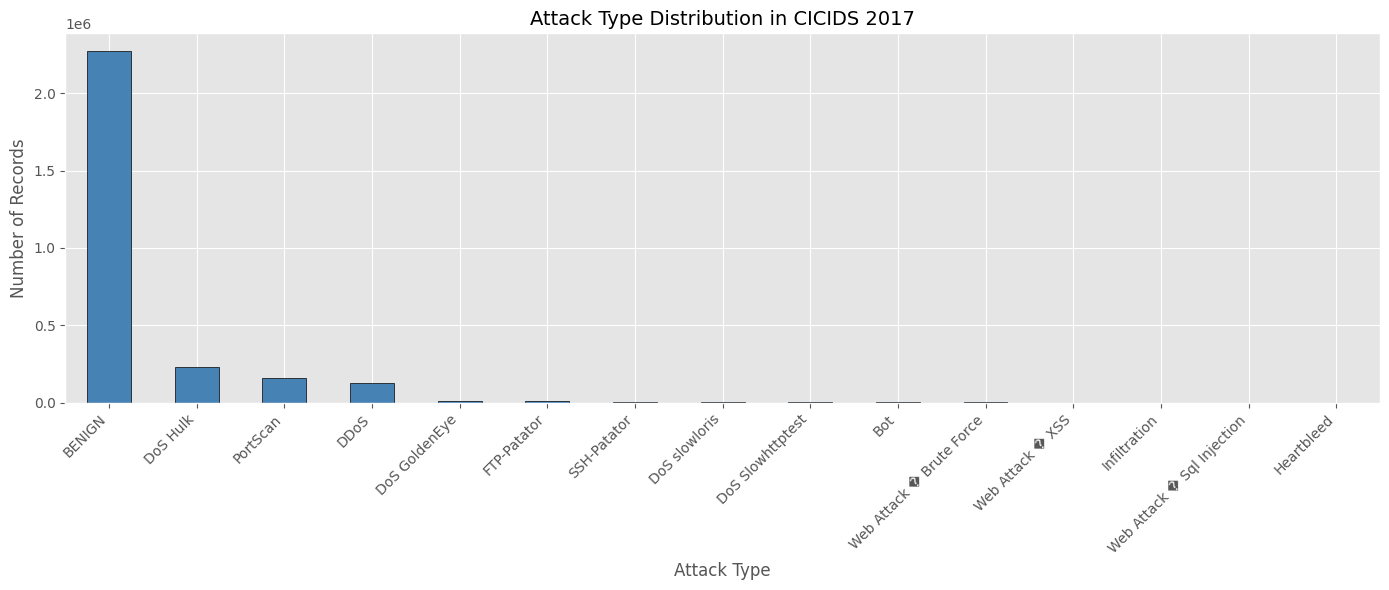

✅ Saved plot to reports/


In [7]:
plt.figure(figsize=(14, 6))
label_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Attack Type Distribution in CICIDS 2017', fontsize=14)
plt.xlabel('Attack Type')
plt.ylabel('Number of Records')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/attack_distribution.png', dpi=150)
plt.show()
print("✅ Saved plot to reports/")

In [8]:
print("🔍 DATA QUALITY REPORT")
print("=" * 50)

# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(f"\n⚠️  Columns with missing values: {len(missing_report)}")
print(missing_report)

# Infinite values
inf_count = np.isinf(df.select_dtypes(include=np.number)).sum().sum()
print(f"\n⚠️  Total infinite values: {inf_count:,}")

# Duplicates
dup_count = df.duplicated().sum()
print(f"\n⚠️  Duplicate rows: {dup_count:,}")

print(f"\n✅ Dataset size: {df.shape[0]:,} rows × {df.shape[1]} columns")

🔍 DATA QUALITY REPORT

⚠️  Columns with missing values: 1
              Missing Count  Missing %
Flow Bytes/s           1358     0.0480

⚠️  Total infinite values: 4,376

⚠️  Duplicate rows: 256,479

✅ Dataset size: 2,830,743 rows × 80 columns
